In [83]:
import pandas as pd
import os
from glob import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Data Preprocessing

In [84]:
#read the data from the balanced files (Oversampled) from the local directory
directory = "D:\\ICSE_Dataset\\CSV_Balanced_CorrectBuggy_Oversampled"

data_points = []
def convert_tensor_to_bool(tensor_str):
    if isinstance(tensor_str, str):
        return 'True' in tensor_str
    elif isinstance(tensor_str, bool):
        return tensor_str
    elif isinstance(tensor_str, int):
        return bool(tensor_str)
    return False

columns_to_delete = []

for filename in os.listdir(directory):
    if filename.endswith('.csv'):
        label = 'buggy' if 'buggy' in filename else 'correct'
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)
        if 'dying_relu' in df.columns:
            df['dying_relu'] = df['dying_relu'].apply(lambda x: convert_tensor_to_bool(x))
        df = df.drop(columns=columns_to_delete, errors='ignore')
        data_point = df.mean().to_frame().T
        data_point['label'] = label
        data_points.append(data_point)

df_combined = pd.concat(data_points, ignore_index=True)
print(df_combined.head())

   epoch  train_loss  train_acc  val_loss   val_acc  large_weight_count  \
0   24.5    0.092246  -2.650498  0.095944 -1.689159                 0.0   
1   24.5    0.113146  -2.412433  0.116135 -1.936848                 0.0   
2   24.5    0.111131  -2.344579  0.109154 -4.260542                 0.0   
3   24.5    0.691411   0.061800  0.694048  0.000000                 0.0   
4   24.5    0.692302   0.334847  0.694626  0.337800                 0.0   

   acc_gap_too_big  loss_oscillation  dying_relu  gradient_vanish  ...  \
0             1.00              0.10         1.0             0.78  ...   
1             0.96              0.12         1.0             0.88  ...   
2             0.96              0.12         1.0             0.90  ...   
3             0.10              0.00         0.0             1.00  ...   
4             0.00              0.00         0.0             1.00  ...   

   gradient_median  adjusted_lr  mean_activation  std_activation  mean_grad  \
0         0.002688     0.

C:\Users\sigma\AppData\Local\Temp\ipykernel_25572\2530788580.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(data_points, ignore_index=True)


In [85]:
data = df_combined.copy()
data.to_csv('D:\\ICSE_Dataset\\1st_Level_OverSampled_with_all_features.csv', index=False)

Start from here if you have the CSV file for the combined dataframe - named as 1st_level_Oversampled/1st_level_Undersampled

In [88]:
df_combined = pd.concat(data_points, ignore_index=True)

C:\Users\sigma\AppData\Local\Temp\ipykernel_25572\18396798.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(data_points, ignore_index=True)


In [89]:
X = df_combined.drop(columns=['label'])
y = df_combined['label']

In [90]:
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)

In [91]:
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.max()), axis=0)

In [92]:
for column in X.columns:
    if X[column].isna().sum() > 0 or np.isinf(X[column]).sum() > 0:
        X[column] = X[column].replace([np.inf, -np.inf], np.nan).fillna(X[column].mean())
    lower_quantile = X[column].quantile(0.01)
    upper_quantile = X[column].quantile(0.99)

    X[column] = X[column].clip(lower=lower_quantile, upper=upper_quantile)

In [93]:
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.mean()), axis=0)

In [94]:
if X.isna().sum().sum() > 0 or np.isinf(X).sum().sum() > 0:
    print("There are still NaNs or infinite values in the DataFrame. Additional cleaning needed.")
else:
    print("Data cleaning completed successfully. No NaNs or infinite values remain.")

Data cleaning completed successfully. No NaNs or infinite values remain.


In [95]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [96]:
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [98]:
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)


X_train shape:  (9931, 31)
X_test shape:  (2483, 31)
y_train shape:  (9931, 2)
y_test shape:  (2483, 2)


In [99]:
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

Feature Importance using Random Forest

Feature ranking:
1. feature 28 (0.209722)
2. feature 30 (0.161475)
3. feature 29 (0.154944)
4. feature 2 (0.083139)
5. feature 4 (0.074002)
6. feature 7 (0.058250)
7. feature 23 (0.050856)
8. feature 9 (0.042791)
9. feature 6 (0.034528)
10. feature 0 (0.032225)
11. feature 8 (0.022934)
12. feature 21 (0.022078)
13. feature 5 (0.012010)
14. feature 10 (0.007429)
15. feature 24 (0.003843)
16. feature 16 (0.003461)
17. feature 26 (0.003345)
18. feature 15 (0.003156)
19. feature 13 (0.003029)
20. feature 19 (0.002758)
21. feature 22 (0.002639)
22. feature 14 (0.002494)
23. feature 27 (0.002439)
24. feature 25 (0.002420)
25. feature 1 (0.001361)
26. feature 20 (0.001048)
27. feature 18 (0.001009)
28. feature 3 (0.000616)
29. feature 12 (0.000000)
30. feature 11 (0.000000)
31. feature 17 (0.000000)


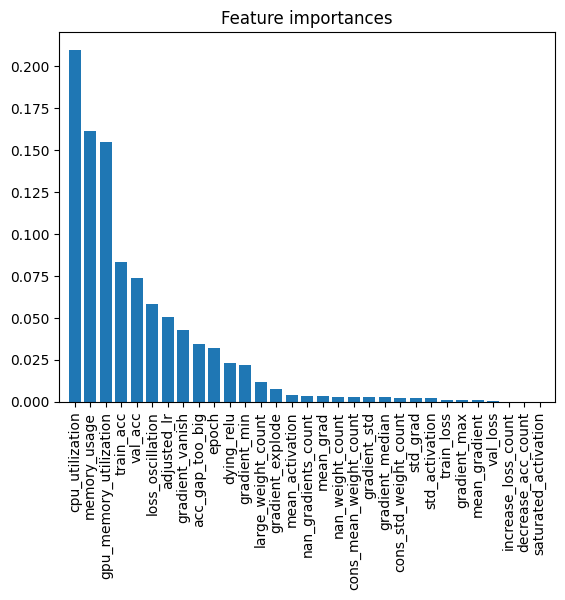

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
importances = clf.feature_importances_

indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure()
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [110]:
# Select features with importance greater than the mean importance
sfm = SelectFromModel(clf, threshold="mean")
sfm.fit(X_train, y_train)
X_important_train = sfm.transform(X_train)
X_important_test = sfm.transform(X_test)

print("Number of features before selection: ", X_train.shape[1])
print("Number of features after selection: ", X_important_train.shape[1])

Number of features before selection:  31
Number of features after selection:  9


Feature importance 

Feature ranking:
1. feature 28 (0.209722)
2. feature 30 (0.161475)
3. feature 29 (0.154944)
4. feature 2 (0.083139)
5. feature 4 (0.074002)
6. feature 7 (0.058250)
7. feature 23 (0.050856)
8. feature 9 (0.042791)
9. feature 6 (0.034528)
10. feature 0 (0.032225)
11. feature 8 (0.022934)
12. feature 21 (0.022078)
13. feature 5 (0.012010)
14. feature 10 (0.007429)
15. feature 24 (0.003843)
16. feature 16 (0.003461)
17. feature 26 (0.003345)
18. feature 15 (0.003156)
19. feature 13 (0.003029)
20. feature 19 (0.002758)
21. feature 22 (0.002639)
22. feature 14 (0.002494)
23. feature 27 (0.002439)
24. feature 25 (0.002420)
25. feature 1 (0.001361)
26. feature 20 (0.001048)
27. feature 18 (0.001009)
28. feature 3 (0.000616)
29. feature 12 (0.000000)
30. feature 11 (0.000000)
31. feature 17 (0.000000)


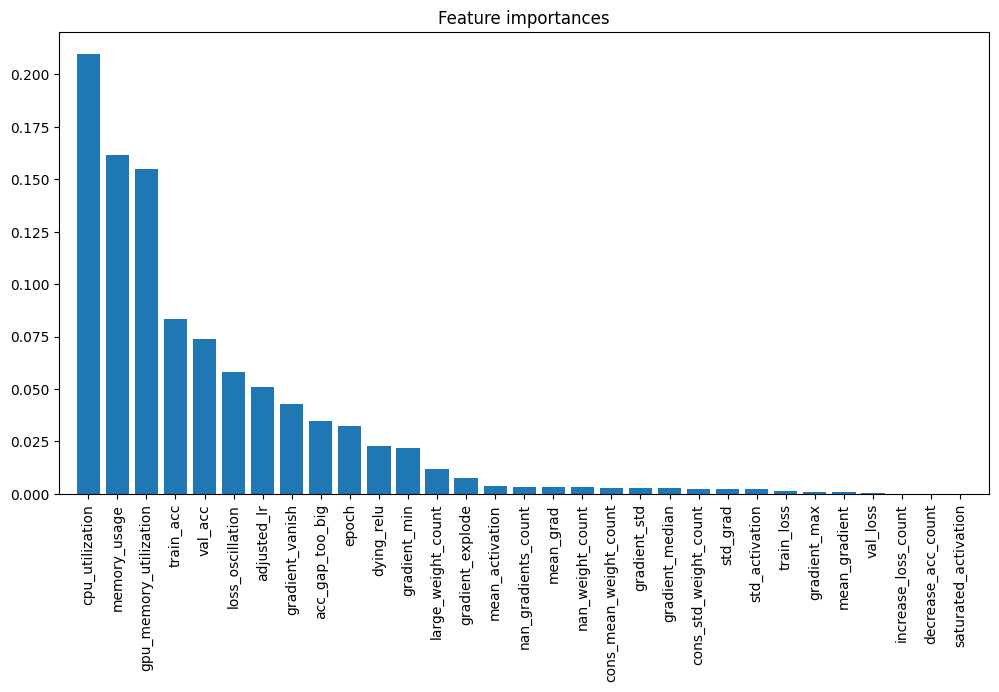

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
importances = clf.feature_importances_

indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))


feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [113]:
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

Feature ranking:
1. feature 28 (0.174547)
2. feature 30 (0.111156)
3. feature 29 (0.092308)
4. feature 7 (0.049255)
5. feature 23 (0.035038)
6. feature 9 (0.030810)
7. feature 2 (0.023198)
8. feature 8 (0.017277)
9. feature 4 (0.016351)
10. feature 6 (0.015626)
11. feature 21 (0.008901)
12. feature 0 (0.008176)
13. feature 10 (0.002416)
14. feature 5 (0.001651)
15. feature 19 (0.000685)
16. feature 3 (0.000403)
17. feature 20 (0.000282)
18. feature 25 (0.000282)
19. feature 22 (0.000161)
20. feature 1 (0.000161)
21. feature 26 (0.000121)
22. feature 18 (0.000121)
23. feature 15 (0.000081)
24. feature 27 (0.000081)
25. feature 17 (0.000000)
26. feature 11 (0.000000)
27. feature 12 (0.000000)
28. feature 13 (-0.000000)
29. feature 14 (-0.000000)
30. feature 16 (-0.000000)
31. feature 24 (-0.000483)


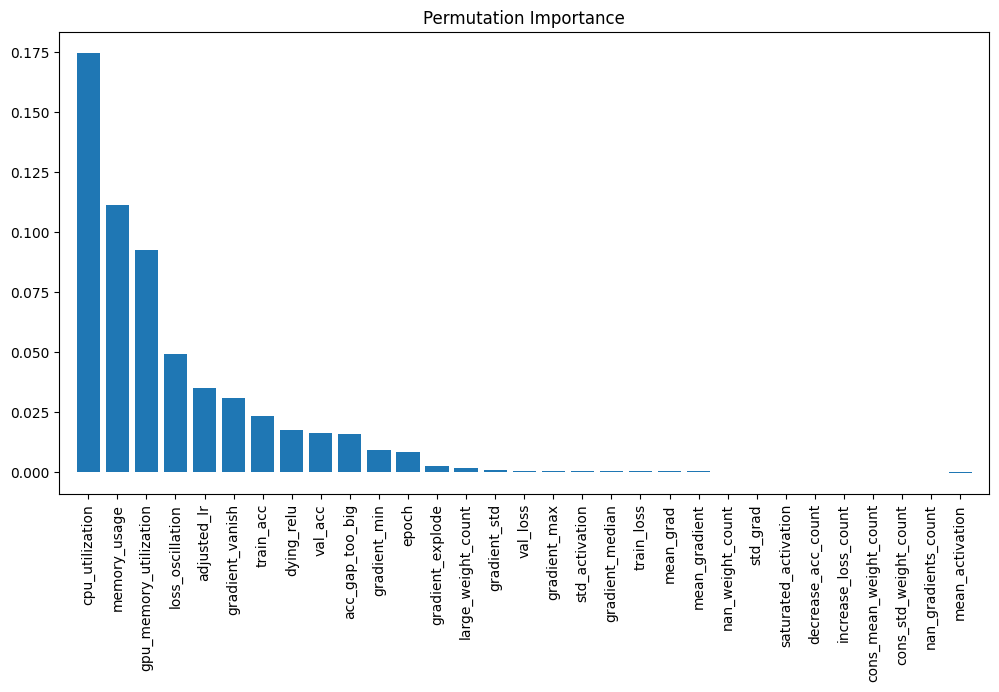

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
indices = result.importances_mean.argsort()[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Permutation Importance")
plt.bar(range(X_train.shape[1]), result.importances_mean[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


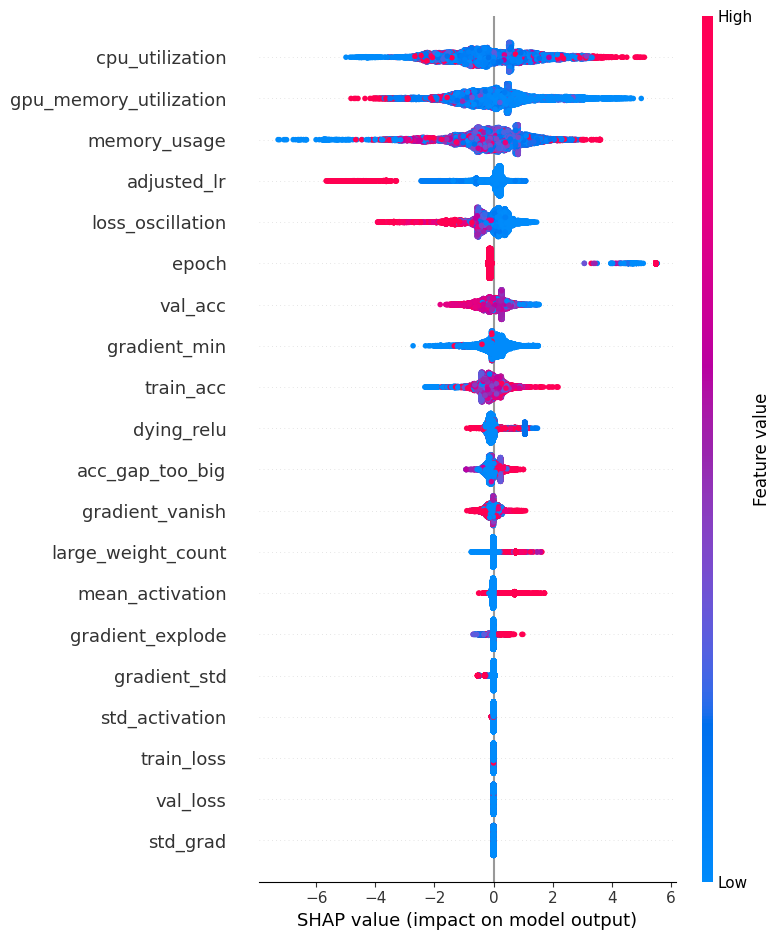

In [115]:
import shap
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
feature_names = X.columns
shap.summary_plot(shap_values, X_train, feature_names=feature_names)


Feature ranking:
1. feature 23 (-1.860811)
2. feature 0 (-1.234442)
3. feature 26 (-1.059448)
4. feature 21 (-0.981652)
5. feature 13 (0.873714)
6. feature 14 (0.873714)
7. feature 19 (0.831399)
8. feature 15 (0.539384)
9. feature 16 (0.521596)
10. feature 24 (0.393734)
11. feature 7 (-0.376965)
12. feature 3 (-0.351402)
13. feature 25 (-0.323132)
14. feature 1 (-0.308602)
15. feature 29 (-0.271484)
16. feature 5 (-0.222874)
17. feature 22 (0.201335)
18. feature 27 (0.186979)
19. feature 10 (0.157805)
20. feature 28 (0.143047)
21. feature 20 (0.128744)
22. feature 18 (0.127612)
23. feature 4 (-0.123562)
24. feature 2 (0.112667)
25. feature 9 (-0.081020)
26. feature 8 (0.056844)
27. feature 6 (-0.023068)
28. feature 30 (0.014041)
29. feature 12 (0.000000)
30. feature 17 (0.000000)
31. feature 11 (0.000000)


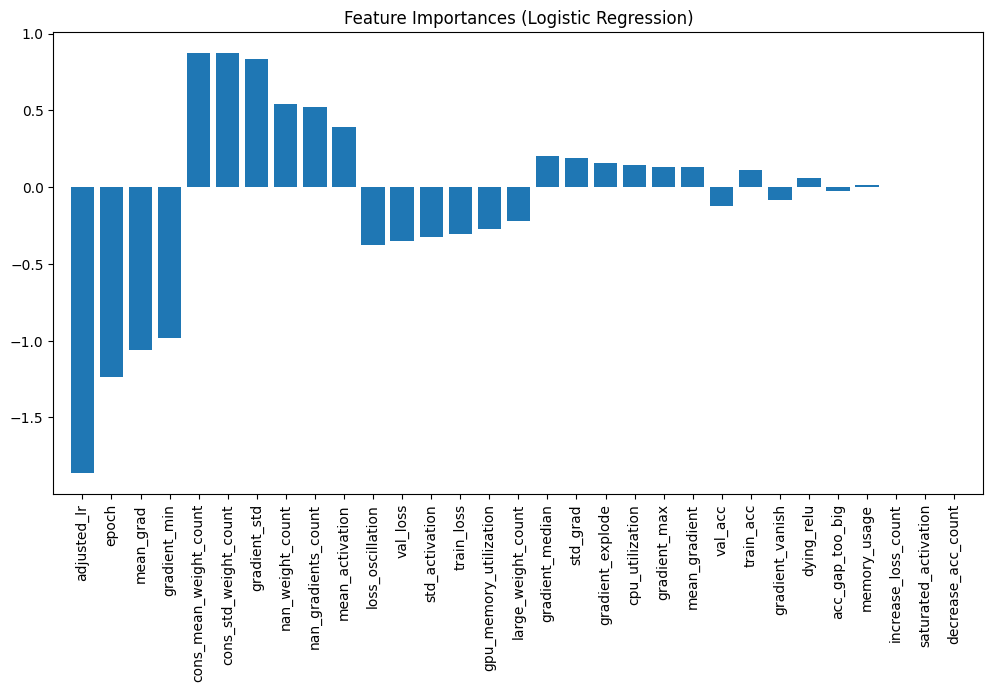

In [116]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
importance = model.coef_[0]
indices = np.argsort(np.abs(importance))[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importance[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Logistic Regression)")
plt.bar(range(X_train.shape[1]), importance[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import shap
import xgboost as xgb
import lime
import lime.lime_tabular
from sklearn.linear_model import LogisticRegression

if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)

if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=X.columns)
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=X.columns)

print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['class_0', 'class_1'],  
    mode='classification'
)

i = 0  
exp = explainer.explain_instance(X_test.iloc[i], model.predict_proba, num_features=10)
exp.show_in_notebook(show_all=False)


Feature ranking:
1. feature 23 (0.035038)
2. feature 0 (0.008176)
3. feature 26 (0.000121)
4. feature 21 (0.008901)
5. feature 13 (-0.000000)
6. feature 14 (-0.000000)
7. feature 19 (0.000685)
8. feature 15 (0.000081)
9. feature 16 (-0.000000)
10. feature 24 (-0.000483)
11. feature 7 (0.049255)
12. feature 3 (0.000403)
13. feature 25 (0.000282)
14. feature 1 (0.000161)
15. feature 29 (0.092308)
16. feature 5 (0.001651)
17. feature 22 (0.000161)
18. feature 27 (0.000081)
19. feature 10 (0.002416)
20. feature 28 (0.174547)
21. feature 20 (0.000282)
22. feature 18 (0.000121)
23. feature 4 (0.016351)
24. feature 2 (0.023198)
25. feature 9 (0.030810)
26. feature 8 (0.017277)
27. feature 6 (0.015626)
28. feature 30 (0.111156)
29. feature 12 (0.000000)
30. feature 17 (0.000000)
31. feature 11 (0.000000)


c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (co

Tree-based classifier - Random Forest


In [118]:
# build a random forest classifier to classify the buggy and correct label based on my training and testing set

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=encoder.categories_[0]))


              precision    recall  f1-score   support

       buggy       0.97      0.99      0.98      1556
     correct       0.98      0.95      0.96       927

    accuracy                           0.97      2483
   macro avg       0.97      0.97      0.97      2483
weighted avg       0.97      0.97      0.97      2483



In [121]:
import numpy as np
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
k = 10
X_train_selected = X_train.iloc[:, indices[:k]]
X_test_selected = X_test.iloc[:, indices[:k]]

In [122]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

clf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(X_train_selected, y_train)
best_clf = grid_search.best_estimator_

Fitting 3 folds for each of 36 candidates, totalling 108 fits


c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [123]:
y_pred = best_clf.predict(X_test_selected)
print(classification_report(y_test, y_pred, target_names=encoder.categories_[0]))

              precision    recall  f1-score   support

       buggy       0.98      0.99      0.98      1556
     correct       0.97      0.96      0.97       927

    accuracy                           0.98      2483
   macro avg       0.98      0.97      0.97      2483
weighted avg       0.98      0.98      0.98      2483



In [125]:
# Enusuring the model is not overfitting
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_clf, X_train_selected, y_train, cv=5, scoring='accuracy')
print("Mean accuracy: ", scores.mean())

Mean accuracy:  0.9721071658631052


In [126]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
clf.fit(X_train, y_train)

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
k = 10 
X_train_selected = X_train.iloc[:, indices[:k]]
X_test_selected = X_test.iloc[:, indices[:k]]

# Hyperparameter Tuning with Cross-Validation
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2'] 
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True),
    param_grid=param_grid,
    cv=5, 
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_selected, y_train)
best_clf = grid_search.best_estimator_


y_pred = best_clf.predict(X_test_selected)
print(classification_report(y_test, y_pred, target_names=encoder.categories_[0]))
print("OOB Score of Best Model: ", best_clf.oob_score_)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits


c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
119 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\base.py", line 666, in _validate_pa

              precision    recall  f1-score   support

       buggy       0.98      0.99      0.98      1556
     correct       0.97      0.96      0.97       927

    accuracy                           0.98      2483
   macro avg       0.98      0.97      0.97      2483
weighted avg       0.98      0.98      0.98      2483

OOB Score of Best Model:  0.9749269962742926


Feature ranking:
1. feature 0 (0.235237)
2. feature 2 (0.172625)
3. feature 1 (0.169629)
4. feature 3 (0.092099)
5. feature 4 (0.076598)
6. feature 6 (0.070188)
7. feature 5 (0.057480)
8. feature 9 (0.055352)
9. feature 7 (0.039244)
10. feature 8 (0.031548)


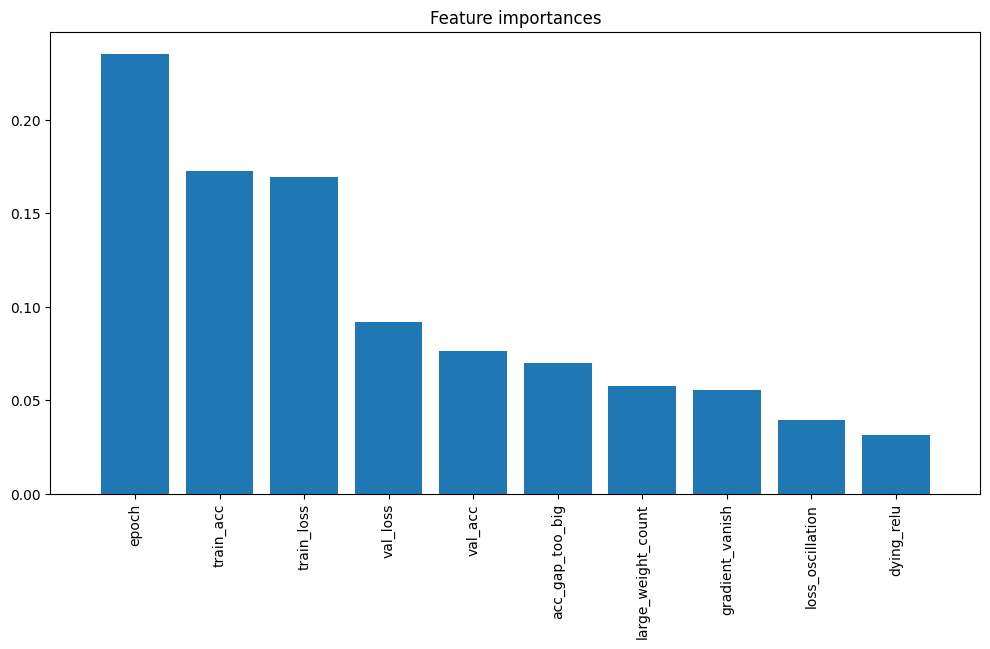

In [128]:
# print the 10 most important features that the model has used to classify the buggy and correct labels
import numpy as np
import matplotlib.pyplot as plt

importances = best_clf.feature_importances_
indices = np.argsort(importances)[::-1]
print("Feature ranking:")

for f in range(X_train_selected.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]

plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(X_train_selected.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_selected.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train_selected.shape[1]])
plt.show()


In [131]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
clf.fit(X_train, y_train)

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
k = 20
X_train_selected = X_train.iloc[:, indices[:k]]
X_test_selected = X_test.iloc[:, indices[:k]]
print("Feature ranking:")
for f in range(X_train_selected.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]

# Hyperparameter Tuning with Cross-Validation
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2'] 
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True),
    param_grid=param_grid,
    cv=5, 
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_selected, y_train)
best_clf = grid_search.best_estimator_

y_pred = best_clf.predict(X_test_selected)
print(classification_report(y_test, y_pred, target_names=encoder.categories_[0]))
print("OOB Score of Best Model: ", best_clf.oob_score_)


Feature ranking:
1. feature 28 (0.209722)
2. feature 30 (0.161475)
3. feature 29 (0.154944)
4. feature 2 (0.083139)
5. feature 4 (0.074002)
6. feature 7 (0.058250)
7. feature 23 (0.050856)
8. feature 9 (0.042791)
9. feature 6 (0.034528)
10. feature 0 (0.032225)
11. feature 8 (0.022934)
12. feature 21 (0.022078)
13. feature 5 (0.012010)
14. feature 10 (0.007429)
15. feature 24 (0.003843)
16. feature 16 (0.003461)
17. feature 26 (0.003345)
18. feature 15 (0.003156)
19. feature 13 (0.003029)
20. feature 19 (0.002758)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
              precision    recall  f1-score   support

       buggy       0.97      0.98      0.98      1556
     correct       0.97      0.95      0.96       927

    accuracy                           0.97      2483
   macro avg       0.97      0.97      0.97      2483
weighted avg       0.97      0.97      0.97      2483

OOB Score of Best Model:  0.9734165743631055


In [ ]:
#prin the best parameters
print("Best Parameters: ", grid_search.best_params_)